In [19]:
from data_utils import index_segmentations_df
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from datetime import datetime
import os
import torch
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
import torch
from segmentation_preprocessing import preprocess_segmentations



from segmentation_training import SegmentationDataset, UNet

Load data

In [20]:
SEGMENTATIONS_DIR = Path.cwd().parents[2] / "AnnotationsData" / "Segmentations"


path_df = index_segmentations_df(
    SEGMENTATIONS_DIR,
    mask_name = 'calculated_masks'
)

mask_quality_df = pd.read_csv('mask_quality_summary.csv')
mask_quality_df = mask_quality_df[['image_path', 'mask_quality']]


mask_quality_df["image_path"] = mask_quality_df["image_path"].apply(Path)

path_df = path_df.merge(mask_quality_df, on = 'image_path', how = 'inner')
print(path_df.columns)

# Only segment the entire cell ie. not just the SOMA
path_df = path_df[path_df['class'] == 'MG_whole']
# Remove all bad annotations
path_df = path_df[~path_df['mask_quality'].isin(['bad', 'bad_image_quality', 'disagree'])]

# path_df = path_df.merg(mask_quality_df, on = )
# Only take first 100 for now to train fast
# path_df = path_df.head(160)
print(len(path_df), "annotation pairs found")


    # First split: train + temp (val+test)
train_df, temp_df = train_test_split(
    path_df,
    test_size=0.3,        # 70% train, 30% temp
    random_state=42,
    shuffle=True
)

# Second split: val + test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,        # 15% val, 15% test
    random_state=42,
    shuffle=True
)

print('Training, validatoin and testing sizes')
print(len(train_df), len(val_df), len(test_df))



train_tfms = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    ToTensorV2()
])

test_tfms = A.Compose([
    A.Resize(256, 256),
    ToTensorV2()
])



train_ds = SegmentationDataset(train_df, train_tfms)
test_ds  = SegmentationDataset(test_df, test_tfms)
val_ds = SegmentationDataset(val_df, test_tfms)


train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=0)


criterion = nn.BCEWithLogitsLoss()
# criterion = DiceLoss()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'currently using device: {device}')

Index(['scan', 'class', 'image_path', 'mask_path', 'mask_quality'], dtype='object')
967 annotation pairs found
Training, validatoin and testing sizes
676 145 146
currently using device: cpu


In [21]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

def _ensure_binary_mask(mask: np.ndarray, thresh=127) -> np.ndarray:
    """Return uint8 binary mask in {0,1}."""
    if mask.ndim == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    if mask.dtype != np.uint8:
        mask = mask.astype(np.uint8)
    # If mask is already 0/1-ish
    if mask.max() <= 1:
        return (mask > 0).astype(np.uint8)
    return (mask >= thresh).astype(np.uint8)

def _clean_mask(mask01: np.ndarray, min_area=200) -> np.ndarray:
    """Remove small components and fill tiny holes a bit."""
    mask = (mask01 * 255).astype(np.uint8)

    # close small gaps
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)

    # keep largest component (often safest for single-cell crops)
    num, labels, stats, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), connectivity=8)
    if num <= 1:
        return (mask > 0).astype(np.uint8)

    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_idx = 1 + int(np.argmax(areas))
    clean = (labels == largest_idx).astype(np.uint8)

    # drop if too small
    if clean.sum() < min_area:
        return clean

    return clean

def _skeletonize(mask01: np.ndarray) -> np.ndarray:
    """
    Try skimage skeletonize; fallback to cv2.ximgproc.thinning if available.
    Returns uint8 {0,1}.
    """
    try:
        from skimage.morphology import skeletonize
        skel = skeletonize(mask01.astype(bool))
        return skel.astype(np.uint8)
    except Exception:
        pass

    # fallback: OpenCV thinning (needs opencv-contrib-python)
    if hasattr(cv2, "ximgproc") and hasattr(cv2.ximgproc, "thinning"):
        skel = cv2.ximgproc.thinning((mask01 * 255).astype(np.uint8))
        return (skel > 0).astype(np.uint8)

    raise ImportError(
        "Skeletonization requires either scikit-image (skimage) "
        "or opencv-contrib-python (cv2.ximgproc.thinning)."
    )

def _cluster_points(points_xy, cluster_radius=6):
    """
    Greedy clustering: merge points within cluster_radius (pixels).
    Returns list of integer (x,y) centroids.
    """
    if len(points_xy) == 0:
        return []

    pts = np.array(points_xy, dtype=np.float32)
    used = np.zeros(len(pts), dtype=bool)
    clusters = []

    for i in range(len(pts)):
        if used[i]:
            continue
        # start a cluster
        seed = pts[i]
        d = np.linalg.norm(pts - seed, axis=1)
        idx = np.where((d <= cluster_radius) & (~used))[0]
        used[idx] = True
        centroid = pts[idx].mean(axis=0)
        clusters.append((int(round(centroid[0])), int(round(centroid[1]))))

    return clusters

def find_branch_soma_connection_points(
    image_path,
    mask_path,
    soma_dist_frac=0.35,
    soma_erode_iters=1,
    candidate_cluster_radius=7,
    debug=False
):
    """
    Parameters
    ----------
    image_path : str|Path
    mask_path : str|Path
    soma_dist_frac : float
        Soma threshold = soma_dist_frac * max(distance_transform).
        Larger => smaller soma; smaller => bigger soma.
    soma_erode_iters : int
        Erode soma a bit so we catch touching skeleton points at boundary robustly.
    candidate_cluster_radius : int
        Cluster candidate pixels into one point per connection.
    debug : bool
        If True, returns intermediate masks too.

    Returns
    -------
    points_xy : list[(x,y)]
    (optional) debug_dict
    """
    image_path = Path(image_path)
    mask_path = Path(mask_path)

    # --- load image (BGR->RGB for plotting) ---
    img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # --- load mask ---
    mask_raw = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if mask_raw is None:
        raise FileNotFoundError(f"Could not read mask: {mask_path}")

    mask01 = _ensure_binary_mask(mask_raw)
    mask01 = _clean_mask(mask01)

    # --- distance transform to estimate soma (thick region) ---
    # dt expects 0/255 uint8
    dt = cv2.distanceTransform((mask01 * 255).astype(np.uint8), distanceType=cv2.DIST_L2, maskSize=5)
    max_dt = float(dt.max()) if dt.size else 0.0
    if max_dt <= 0:
        return ([], {"reason": "empty mask"}) if debug else []

    soma = (dt >= soma_dist_frac * max_dt).astype(np.uint8)

    # keep largest soma component (in case branches contain thicker bits)
    num, labels, stats, _ = cv2.connectedComponentsWithStats(soma, connectivity=8)
    if num > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        soma = (labels == (1 + int(np.argmax(areas)))).astype(np.uint8)

    # optional erosion so boundary-touch detection is stable
    if soma_erode_iters > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        soma = cv2.erode(soma, k, iterations=soma_erode_iters)

    # --- skeletonize whole cell mask ---
    skel = _skeletonize(mask01)

    # --- soma boundary band: dilate(soma) - soma ---
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    soma_dil = cv2.dilate(soma, k, iterations=1)
    soma_boundary_band = (soma_dil & (1 - soma)).astype(np.uint8)

    # candidate connection pixels: skeleton that lies in boundary band
    candidates = (skel & soma_boundary_band).astype(np.uint8)

    # get candidate pixel coords (x,y)
    ys, xs = np.where(candidates > 0)
    pts = list(zip(xs.tolist(), ys.tolist()))

    # cluster to one point per connection
    points_xy = _cluster_points(pts, cluster_radius=candidate_cluster_radius)

    if debug:
        dbg = {
            "mask01": mask01,
            "dt": dt,
            "soma": soma,
            "skel": skel,
            "soma_boundary_band": soma_boundary_band,
            "candidates": candidates,
        }
        return points_xy, dbg

    return points_xy

def draw_crosses(img_rgb, points_xy, size=8, thickness=2):
    """Return a copy with cross markers drawn."""
    out = img_rgb.copy()
    for (x, y) in points_xy:
        # draw an "X"
        cv2.line(out, (x - size, y - size), (x + size, y + size), (0, 255, 0), thickness)
        cv2.line(out, (x - size, y + size), (x + size, y - size), (0, 255, 0), thickness)
    return out

# ----------------- Example usage -----------------


    # Optional debug views
    # plt.figure(); plt.imshow(dbg["soma"], cmap="gray"); plt.title("Soma"); plt.axis("off"); plt.show()
    # plt.figure(); plt.imshow(dbg["skel"], cmap="gray"); plt.title("Skeleton"); plt.axis("off"); plt.show()
    # plt.figure(); plt.imshow(dbg["candidates"], cmap="gray"); plt.title("Candidate boundary hits"); plt.axis("off"); plt.show()


In [22]:
print(train_df.columns)

Index(['scan', 'class', 'image_path', 'mask_path', 'mask_quality'], dtype='object')


In [23]:
import cv2
import matplotlib.pyplot as plt

def visualize_first_n(train_df, n=5):
    for i, row in train_df.head(n).iterrows():
        image_path = row["image_path"]
        mask_path  = row["mask_path"]

        points = find_branch_soma_connection_points(
            image_path,
            mask_path,
            soma_dist_frac=0.35,
            candidate_cluster_radius=7,
            debug=False
        )

        img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        vis = draw_crosses(img_rgb, points, size=1, thickness=1)

        plt.figure(figsize=(6, 6))
        plt.imshow(vis)
        plt.axis("off")
        plt.title(
            f"{row['scan']} | {row['class']} | "
            f"{len(points)} connections"
        )
        plt.show()


In [24]:
# visualize_first_n(train_df, n=4)


In [25]:
def sample_random_background_patch(image, mask01, patch_h, patch_w, max_tries=100):
    """
    Sample a random background-only patch from the image.

    Parameters
    ----------
    image : np.ndarray (H, W, 3)
    mask01 : np.ndarray (H, W), binary (1 = foreground)
    patch_h, patch_w : int
        Size of patch to sample
    max_tries : int
        Number of attempts before giving up

    Returns
    -------
    patch : np.ndarray (patch_h, patch_w, 3)
    """

    H, W = mask01.shape

    for _ in range(max_tries):
        y0 = np.random.randint(0, H - patch_h + 1)
        x0 = np.random.randint(0, W - patch_w + 1)

        patch_mask = mask01[y0:y0 + patch_h, x0:x0 + patch_w]

        # require full background
        if patch_mask.sum() == 0:
            return image[y0:y0 + patch_h, x0:x0 + patch_w].copy()

    # fallback: return a white patch if no background found
    return np.full((patch_h, patch_w, 3), 0, dtype=image.dtype)


In [26]:
def feather_blend_box(
    image,
    image_modified,
    x0, y0, x1, y1,
    feather_radius=10
):
    """
    Feather-blend a rectangular region so its edges are not noticeable.

    Parameters
    ----------
    image : np.ndarray (H, W, 3)
        Original image
    image_modified : np.ndarray (H, W, 3)
        Image after box modification (background fill, white box, etc.)
    x0, y0, x1, y1 : int
        Box coordinates
    feather_radius : int
        Width of edge blending (pixels)
    """

    H, W = image.shape[:2]

    # 1. Create box mask
    mask = np.zeros((H, W), dtype=np.float32)
    mask[y0:y1, x0:x1] = 1.0

    # 2. Blur mask → soft edges
    k = max(3, feather_radius * 2 + 1)
    mask = cv2.GaussianBlur(mask, (k, k), 0)

    # Normalize to [0,1]
    mask = mask / (mask.max() + 1e-6)

    mask = mask[..., None]  # (H,W,1)

    # 3. Alpha blend
    blended = (
        mask * image_modified.astype(np.float32) +
        (1 - mask) * image.astype(np.float32)
    )

    return blended.astype(image.dtype)


In [27]:
def disconnect_branches_with_gap(
    image_path,
    mask_path,
    points_xy,
    box_size=15,
    blur_output=True,
    blur_ksize=15,
    feather=10
):
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    mask  = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise FileNotFoundError(image_path)
    if mask is None:
        raise FileNotFoundError(mask_path)

    mask01 = (mask > 0).astype(np.uint8)

    image_out = image.copy()
    mask_out  = mask01.copy()

    half = box_size // 2
    H, W = mask01.shape

    for (x, y) in points_xy:
        x, y = int(x), int(y)

        x0 = max(0, x - half)
        x1 = min(W, x + half + 1)
        y0 = max(0, y - half)
        y1 = min(H, y + half + 1)

        ph = y1 - y0
        pw = x1 - x0

        # sample background patch
        bg_patch = sample_random_background_patch(
            image,
            mask01,
            ph,
            pw
        )

        fg_region = mask01[y0:y1, x0:x1] == 1
        image_out[y0:y1, x0:x1][fg_region] = bg_patch[fg_region]
        mask_out[y0:y1, x0:x1] = 0

        # --- optional blur ---
        if blur_output:
            image_out = feather_blend_box(
                image=image,
                image_modified=image_out,
                x0=x0, y0=y0, x1=x1, y1=y1,
                feather_radius=12
            )

    return image_out, mask_out


In [28]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def visualize_first_n_with_branch_cuts(
    train_df,
    n=5,
    box_size = 15,
    show_points=True, 
    blur_output = True, 
):
    """
    Visualize branch disconnections for the first n rows of train_df.

    Parameters
    ----------
    train_df : pd.DataFrame
        Must contain image_path and mask_path
    n : int
        Number of rows to visualize
    gap_length : int
        Length of the cut gap (pixels)
    gap_width : int
        Width of the cut gap (pixels)
    show_points : bool
        Whether to overlay branch–soma connection points
    """

    for i, row in train_df.head(n).iterrows():
        image_path = row["image_path"]
        mask_path  = row["mask_path"]

        # --- find branch connection points ---
        points = find_branch_soma_connection_points(
            image_path,
            mask_path,
            soma_dist_frac=0.35,
            candidate_cluster_radius=7,
            debug=False
        )

        # --- cut branches locally ---
        image_cut, _ = disconnect_branches_with_gap(
            image_path,
            mask_path,
            points, 
            box_size = box_size,
            blur_output = blur_output
        )

        # --- convert to RGB for plotting ---
        image_cut_rgb = cv2.cvtColor(image_cut, cv2.COLOR_BGR2RGB)

        # --- optionally overlay connection points ---
        if show_points:
            image_cut_rgb = draw_crosses(
                image_cut_rgb,
                points,
                size=2,
                thickness=1
            )

        # --- show ---
        plt.figure(figsize=(6, 6))
        plt.imshow(image_cut_rgb)
        plt.axis("off")
        plt.title(
            f"{row['scan']} | {row['class']} | "
            f"{len(points)} cuts"
        )
        plt.show()


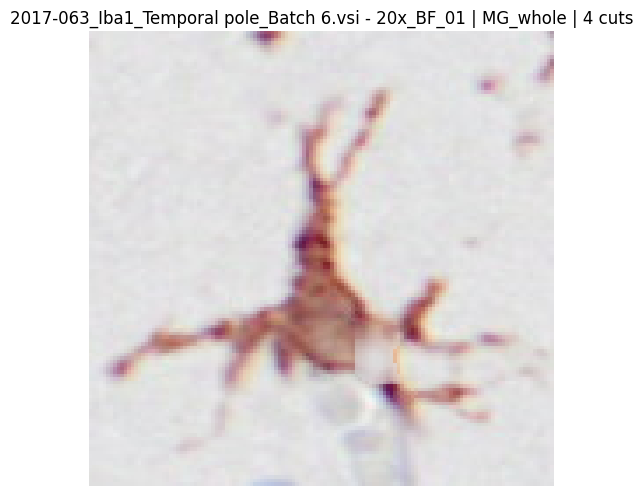

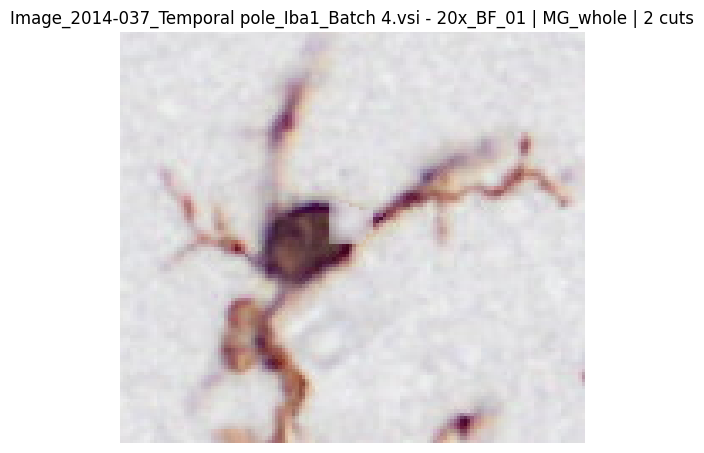

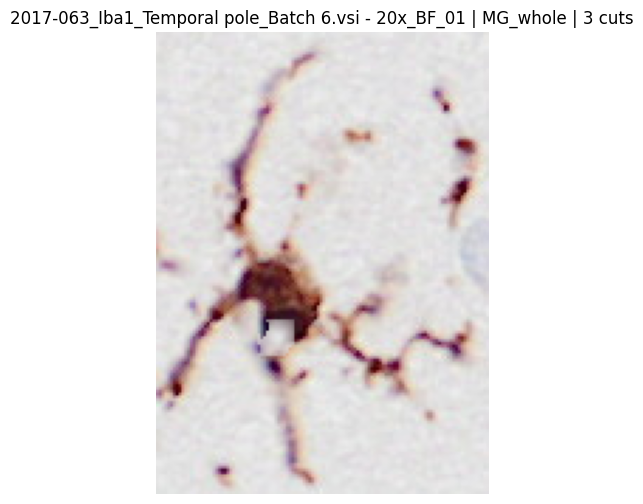

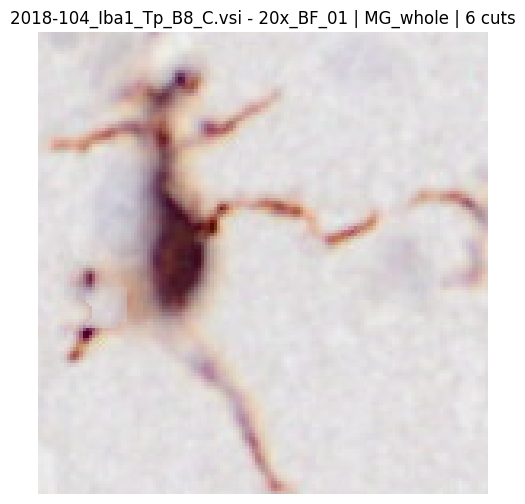

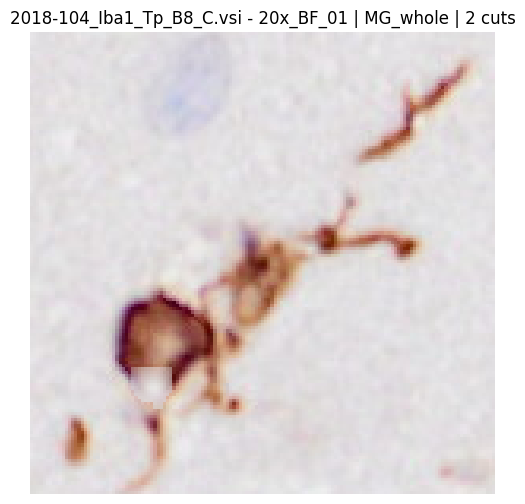

In [31]:
visualize_first_n_with_branch_cuts(
    train_df,
    n=5,
    box_size = 12,
    show_points=False,
    blur_output = True
)
